# Extended Lab: Data Types, Distributions & Resampling Methods

This lab extends the material from *Building Statistical Models in Python*, Chapter 2
(Data Types, Distributions, Bootstrapping, Permutations, Transformations).

It is organized into **six modules**. Each module has:
- A short theory recap
- Worked examples (fully run, with output)
- **Extended exercises** that go beyond the book's examples (marked `>>> EXERCISE`)
- A "Check yourself" question to test understanding

> This is the **fully worked / answer-key style** notebook. If you want to practice
> from a blank slate, use `skeleton_notebook.ipynb` instead and check your work
> against `solutions_notebook.ipynb`.

**Environment used in this lab:**
```
numpy, scipy, pandas, matplotlib, seaborn, statsmodels
```


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations

np.random.seed(42)  # reproducibility across the whole lab
plt.rcParams['figure.figsize'] = (9, 4.5)


---
## Module 1 — Types of Data

| Type | Supports | Example |
|---|---|---|
| Nominal | equality (=, ≠) | machine model, blood type |
| Ordinal | equality + order | education level, star rating |
| Interval | equality + order + (+ / −) | temperature in °C |
| Ratio | equality + order + (+ / −) + (× / ÷), has true zero | wait time, income, weight |

The type of data you have **determines which statistics and operations are valid**.
For example, computing a *mean* of nominal data (e.g., "average machine model") is
meaningless, but computing a *mode* is fine.


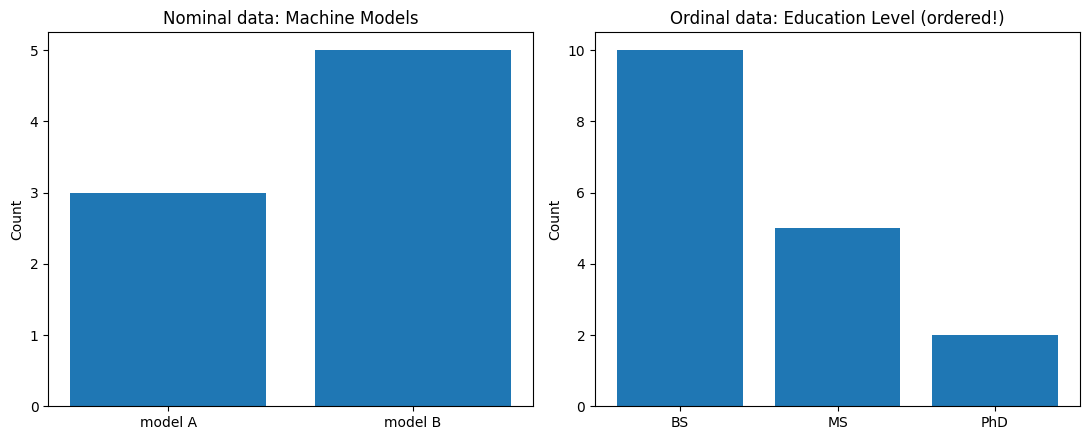

In [2]:
# Nominal + ordinal example (from the book), recreated
label = ['model A', 'model B']
counts = [3, 5]

edu_label = ['BS', 'MS', 'PhD']
edu_counts = [10, 5, 2]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].bar(label, counts)
ax[0].set_title('Nominal data: Machine Models')
ax[0].set_ylabel('Count')

ax[1].bar(edu_label, edu_counts)
ax[1].set_title('Ordinal data: Education Level (ordered!)')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


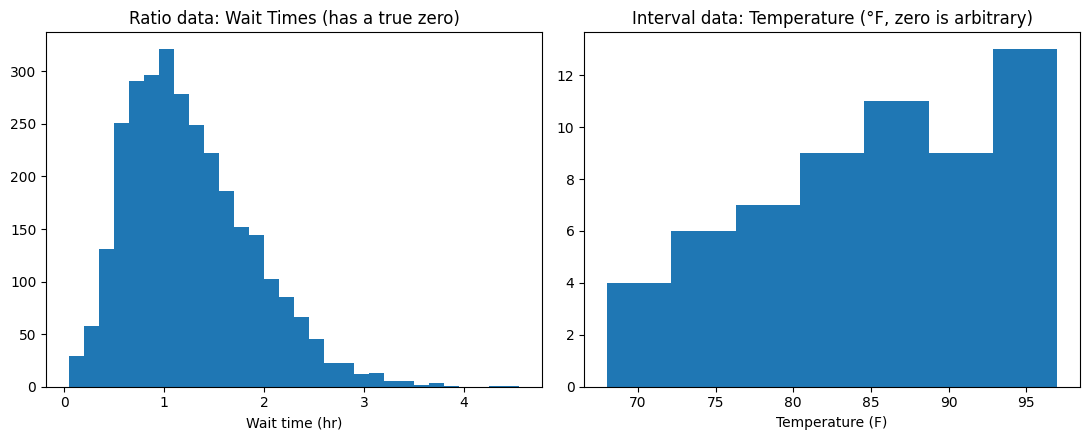

In [3]:
# Interval vs ratio example
dfw_highs = [85, 87, 75, 88, 80, 86, 90, 94, 93, 92, 90, 92, 94, 93, 97, 90, 95, 96,
             96, 95, 92, 70, 79, 73, 88, 92, 94, 93, 95, 76, 78, 86, 81, 95, 77, 71,
             69, 88, 86, 89, 84, 82, 77, 84, 81, 79, 75, 75, 91, 86, 86, 84, 82, 68,
             75, 78, 82, 83, 85]

wait_times = stats.skewnorm.rvs(4, size=3000) + 0.5
wait_times = wait_times[wait_times > 0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].hist(wait_times, bins=30)
ax[0].set_title('Ratio data: Wait Times (has a true zero)')
ax[0].set_xlabel('Wait time (hr)')

ax[1].hist(dfw_highs, bins=7)
ax[1].set_title('Interval data: Temperature (°F, zero is arbitrary)')
ax[1].set_xlabel('Temperature (F)')
plt.tight_layout()
plt.show()


### >>> EXERCISE 1.1 — Classify the data
For each variable below, state whether it is **nominal, ordinal, interval, or ratio**
and justify in one sentence:

1. Customer satisfaction: "Unhappy", "Neutral", "Happy"
2. Zip code
3. Number of children in a household
4. Credit score (300–850)
5. Date on the Hijri calendar
6. Marathon finishing time in minutes

*(Answer in the markdown cell below — this is a conceptual exercise, no code needed.)*


_Your answer here._

### >>> EXERCISE 1.2 — Build your own visualization
Using `matplotlib`, create a **bar chart** for the following ordinal variable
(movie ratings: G, PG, PG-13, R) with counts `[12, 30, 45, 18]`, making sure the
x-axis preserves the natural order. Add title and axis labels.


In [4]:
# >>> EXERCISE 1.2 — your code here


---
## Module 2 — Descriptive Statistics & the Normal Distribution

**Central tendency:** mode, median, mean
**Variability:** range, IQR, Tukey fences, variance, standard deviation
**Shape:** skewness, kurtosis

Then: the **normal distribution**, the **Empirical Rule** (68/95/99.7), and the
**Central Limit Theorem** (CLT) — the bridge to bootstrapping in Module 3.


In [5]:
values = [85, 99, 70, 71, 86, 88, 94]

mean = np.mean(values)
median = np.median(values)
mode_result = stats.mode(values, keepdims=True)

variance = np.var(values, ddof=1)      # ddof=1 -> sample variance (N-1 denominator)
std_dev = np.std(values, ddof=1)

q1, q2, q3 = np.quantile(values, [0.25, 0.5, 0.75], method='closest_observation')
iqr = stats.iqr(values, interpolation='closest_observation')

print(f"Mean:     {mean:.2f}")
print(f"Median:   {median:.2f}")
print(f"Mode:     {mode_result.mode[0]} (count={mode_result.count[0]})")
print(f"Variance: {variance:.2f}   Std Dev: {std_dev:.2f}")
print(f"Q1={q1}, Q2(median)={q2}, Q3={q3}, IQR={iqr}")


Mean:     84.71
Median:   86.00
Mode:     70 (count=1)
Variance: 117.90   Std Dev: 10.86
Q1=71, Q2(median)=86, Q3=88, IQR=17.0


> **Note on `ddof`:** the book's `np.var`/`np.std` examples use the *population*
> formula (`ddof=0`, divide by N). For a **sample** meant to estimate a population
> parameter (the far more common real-world case), use `ddof=1` (divide by N−1),
> which is what `scipy`'s formulas assume. Always check which one a function
> defaults to before you compare numbers across libraries.


Tukey fences: [45.50, 113.50]  (points outside are flagged as outliers)


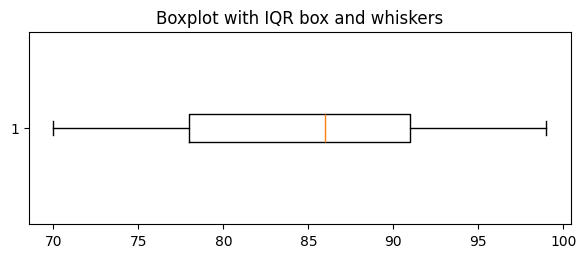

In [6]:
# Tukey fences -> outlier detection
k = 1.5
lower_fence = q1 - k * iqr
upper_fence = q3 + k * iqr
print(f"Tukey fences: [{lower_fence:.2f}, {upper_fence:.2f}]  (points outside are flagged as outliers)")

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.boxplot(values, vert=False)
ax.set_title('Boxplot with IQR box and whiskers')
plt.show()


In [7]:
# Skewness & kurtosis on three synthetic shapes
skew_left = -stats.skewnorm.rvs(10, size=3000) + 4
skew_right = stats.skewnorm.rvs(10, size=3000) + 3
symmetric = stats.norm.rvs(10, size=3000)

for name, arr in [('left-skewed', skew_left), ('right-skewed', skew_right), ('symmetric', symmetric)]:
    print(f"{name:12s} skew={stats.skew(arr):+.3f}  kurtosis={stats.kurtosis(arr):+.3f}")


left-skewed  skew=-0.987  kurtosis=+0.999
right-skewed skew=+0.991  kurtosis=+0.821
symmetric    skew=-0.017  kurtosis=+0.074


### The Normal Distribution & Empirical Rule


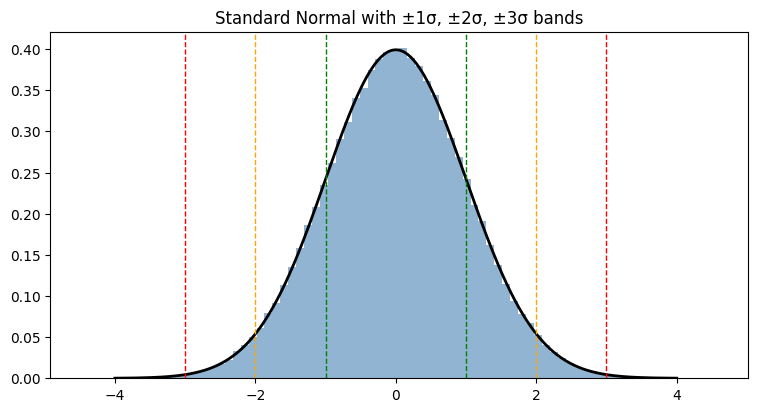

Within 1σ: 68.2% (expect ~68.3%)
Within 2σ: 95.4% (expect ~95.4%)
Within 3σ: 99.7% (expect ~99.7%)


In [8]:
data = np.random.randn(200_000)
mu, sigma = data.mean(), data.std()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(data, bins=80, density=True, alpha=0.6, color='steelblue')

x = np.linspace(-4, 4, 400)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color='black', lw=2)

for k, color in zip([1, 2, 3], ['green', 'orange', 'red']):
    ax.axvline(mu + k*sigma, color=color, ls='--', lw=1)
    ax.axvline(mu - k*sigma, color=color, ls='--', lw=1)

ax.set_title('Standard Normal with ±1σ, ±2σ, ±3σ bands')
plt.show()

within_1 = np.mean(np.abs(data - mu) < sigma)
within_2 = np.mean(np.abs(data - mu) < 2*sigma)
within_3 = np.mean(np.abs(data - mu) < 3*sigma)
print(f"Within 1σ: {within_1:.1%} (expect ~68.3%)")
print(f"Within 2σ: {within_2:.1%} (expect ~95.4%)")
print(f"Within 3σ: {within_3:.1%} (expect ~99.7%)")


### Central Limit Theorem (CLT) demo
Draw samples from a **very non-normal** population (exponential) and show that the
*distribution of sample means* still converges to a normal shape as sample size grows.


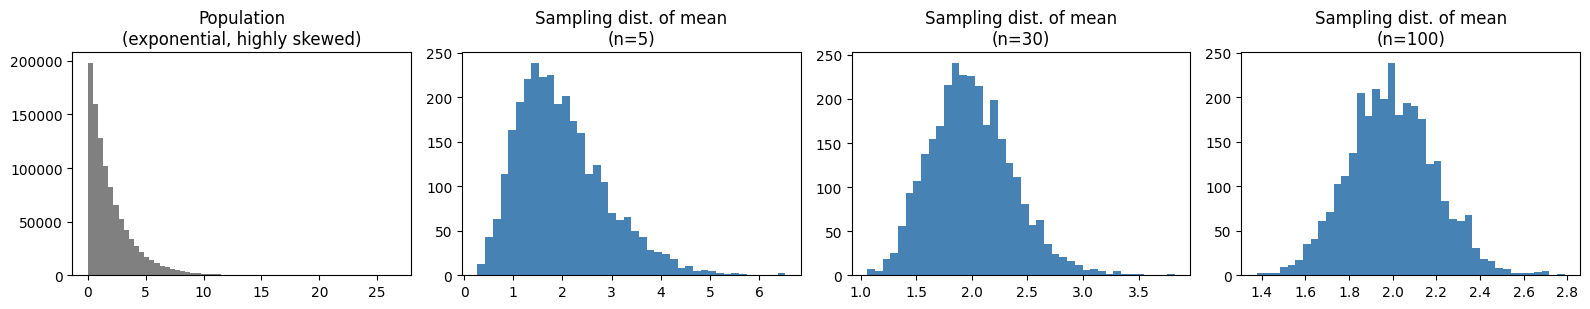

Notice: even though the population is exponential (right-skewed), the
sampling distribution of the mean becomes bell-shaped as n grows. This is the CLT.


In [9]:
population = np.random.exponential(scale=2.0, size=1_000_000)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
axes[0].hist(population, bins=60, color='gray')
axes[0].set_title('Population\n(exponential, highly skewed)')

for ax, n in zip(axes[1:], [5, 30, 100]):
    sample_means = [population[np.random.randint(0, len(population), n)].mean() for _ in range(3000)]
    ax.hist(sample_means, bins=40, color='steelblue')
    ax.set_title(f'Sampling dist. of mean\n(n={n})')
plt.tight_layout()
plt.show()
print("Notice: even though the population is exponential (right-skewed), the")
print("sampling distribution of the mean becomes bell-shaped as n grows. This is the CLT.")


### >>> EXERCISE 2.1
Using `np.random.uniform(0, 1, size=1_000_000)` as the population (a *flat*, non-normal
distribution), reproduce the CLT demo above with sample sizes `n = 2, 10, 50`.
Does the sampling distribution of the mean still look normal? Why does CLT not care
that the *population* shape is uniform rather than exponential?


In [10]:
# >>> EXERCISE 2.1 — your code here


### >>> EXERCISE 2.2 — Robustness of mean vs. median
Take `values = [85, 99, 70, 71, 86, 88, 94]`, then add one extreme outlier
(`10000`) to the list. Recompute the mean and median before/after. Which
measure moved more? Explain in one sentence why that happens.


In [11]:
# >>> EXERCISE 2.2 — your code here


---
## Module 3 — Bootstrapping

Bootstrapping estimates the sampling distribution of a statistic (mean, median,
correlation, ...) by **resampling with replacement** from the observed sample. It
relies on the CLT from Module 2: means of enough resamples approximate normality.

We use the `Duncan` occupational-prestige dataset (income, education, and prestige by
job type) bundled with `statsmodels`/R's `carData`, exactly as in the book.


In [12]:
df_duncan = sm.datasets.get_rdataset("Duncan", "carData").data
df_duncan.loc[df_duncan['type'] == 'prof', 'type'] = 'professional'
df_duncan.loc[df_duncan['type'] == 'wc', 'type'] = 'white-collar'
df_duncan.loc[df_duncan['type'] == 'bc', 'type'] = 'blue-collar'

df_professional = df_duncan.loc[df_duncan['type'] == 'professional']
df_blue_collar = df_duncan.loc[df_duncan['type'] == 'blue-collar']

print(df_duncan.shape)
df_duncan.head()


(45, 4)


,type,income,education,prestige
rownames,,,,
accountant,professional,62,86,82
pilot,professional,72,76,83
architect,professional,75,92,90
author,professional,55,90,76
chemist,professional,64,86,90


Professional 95% CI: (np.float64(49.22), np.float64(69.78))  mean: 60.05
Blue-collar  95% CI: (np.float64(14.3), np.float64(35.7))  mean: 23.8


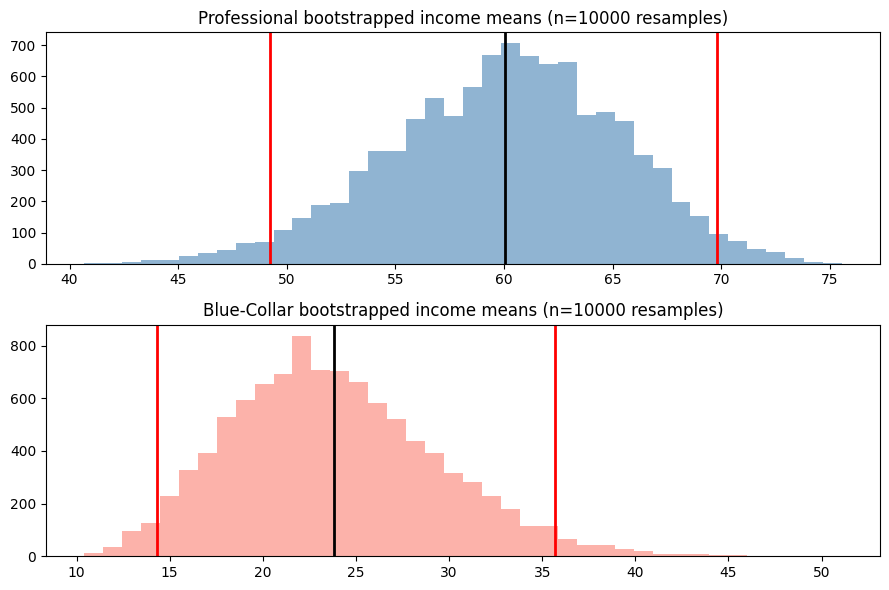

In [13]:
def bootstrap_means(sample, n_replicas=10000, frac=0.5, replace=True, seed=None):
    '''Return an array of n_replicas bootstrap means drawn from `sample`.'''
    rng = np.random.default_rng(seed)
    sample = np.asarray(sample)
    n = max(1, int(len(sample) * frac))
    return np.array([rng.choice(sample, size=n, replace=replace).mean() for _ in range(n_replicas)])

prof_boot = bootstrap_means(df_professional['income'], n_replicas=10000, seed=1)
blue_boot = bootstrap_means(df_blue_collar['income'], n_replicas=10000, seed=2)

def ci(arr, p=5):
    return np.percentile(arr, p/2), np.percentile(arr, 100 - p/2)

print("Professional 95% CI:", tuple(round(v, 2) for v in ci(prof_boot)), " mean:", round(prof_boot.mean(), 2))
print("Blue-collar  95% CI:", tuple(round(v, 2) for v in ci(blue_boot)), " mean:", round(blue_boot.mean(), 2))

fig, ax = plt.subplots(2, 1, figsize=(9, 6))
for a, boot, label, color in zip(ax, [prof_boot, blue_boot], ['Professional', 'Blue-Collar'], ['steelblue', 'salmon']):
    a.hist(boot, bins=40, alpha=0.6, color=color)
    lo, hi = ci(boot)
    a.axvline(boot.mean(), color='black', lw=2)
    a.axvline(lo, color='red', lw=2)
    a.axvline(hi, color='red', lw=2)
    a.set_title(f'{label} bootstrapped income means (n=10000 resamples)')
plt.tight_layout()
plt.show()


Since the two 95% confidence intervals **do not overlap**, we have evidence of a
statistically meaningful difference in mean income between the two job types —
even though the raw sample sizes (18 and 21) were far too small to trust a
single point estimate. This is the payoff of bootstrapping: getting a
distribution (and therefore a CI), not just one number.


In [14]:
# Standard error shrinks as n_replicas grows... but note: what really matters for SE
# is the ORIGINAL sample size, not n_replicas. Let's demonstrate both effects.
for n_rep in [10, 100, 1000, 10000]:
    boot = bootstrap_means(df_professional['income'], n_replicas=n_rep, seed=0)
    print(f"n_replicas={n_rep:6d}  SE={stats.sem(boot):.3f}  (SE of the bootstrap DISTRIBUTION, "
          f"not the original data)")


n_replicas=    10  SE=0.942  (SE of the bootstrap DISTRIBUTION, not the original data)
n_replicas=   100  SE=0.608  (SE of the bootstrap DISTRIBUTION, not the original data)
n_replicas=  1000  SE=0.167  (SE of the bootstrap DISTRIBUTION, not the original data)
n_replicas= 10000  SE=0.053  (SE of the bootstrap DISTRIBUTION, not the original data)


Original sample correlation: 0.725
Bootstrap mean correlation:  0.724
Bootstrap 95% CI:            (np.float64(0.517), np.float64(0.882))


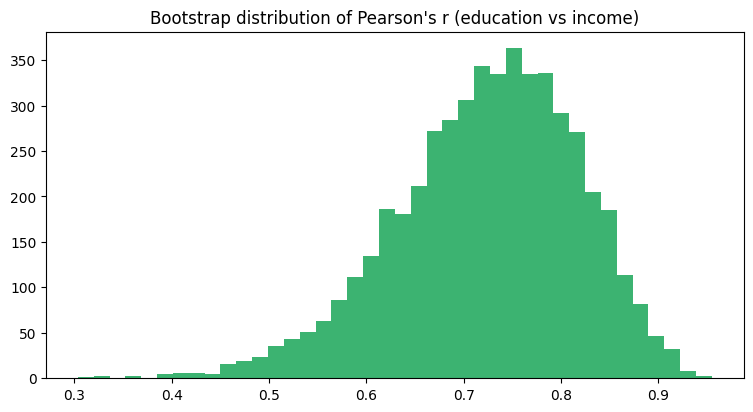

In [15]:
# Bootstrapped correlation coefficient (Pearson's r) between education and income
corr_boot = []
rng = np.random.default_rng(3)
idx = np.arange(len(df_duncan))
for _ in range(5000):
    sample_idx = rng.choice(idx, size=len(idx), replace=True)
    sub = df_duncan.iloc[sample_idx]
    r, _ = stats.pearsonr(sub['education'], sub['income'])
    corr_boot.append(r)
corr_boot = np.array(corr_boot)

print(f"Original sample correlation: {stats.pearsonr(df_duncan['education'], df_duncan['income'])[0]:.3f}")
print(f"Bootstrap mean correlation:  {corr_boot.mean():.3f}")
print(f"Bootstrap 95% CI:            {tuple(round(v,3) for v in ci(corr_boot))}")

plt.hist(corr_boot, bins=40, color='mediumseagreen')
plt.title("Bootstrap distribution of Pearson's r (education vs income)")
plt.show()


### >>> EXERCISE 3.1 — Bootstrap the median
The book's example bootstraps the **mean**. Modify `bootstrap_means` (or write a
new function `bootstrap_stat(sample, stat_fn, ...)`) to bootstrap the **median**
income for `professional` vs `blue-collar`. Do the 95% CIs still separate?


In [16]:
# >>> EXERCISE 3.1 — your code here


### >>> EXERCISE 3.2 — Sample size sensitivity
Repeat the professional-vs-blue-collar CI comparison, but this time bootstrap from
only the **first 5 rows** of each group (`df_professional.head(5)`,
`df_blue_collar.head(5)`). What happens to the width of the confidence intervals?
Why is this a warning sign about bootstrapping tiny samples?


In [17]:
# >>> EXERCISE 3.2 — your code here


---
## Module 4 — Permutations, Combinations, and Permutation Testing

- **Permutation**: an *ordered* arrangement — order matters. `P(n,r) = n! / (n-r)!`
- **Combination**: an *unordered* selection — order doesn't matter. `C(n,r) = n! / (r!(n-r)!)`
- **Permutation testing**: a non-parametric hypothesis test. Pool two samples, shuffle
  repeatedly, and see how often a random shuffle produces a difference-of-means as
  extreme as the one observed. No normality assumption required.


In [18]:
people = [f'P{i}' for i in range(1, 11)]

perm_3 = list(permutations(people, 3))
comb_3 = list(combinations(people, 3))
perm_all = list(permutations(people))

print(f"Ordered selections of 3 from 10 (permutations): {len(perm_3)}  (expect 10*9*8 = {10*9*8})")
print(f"Unordered selections of 3 from 10 (combinations): {len(comb_3)}  (expect 720/6 = {720//6})")
print(f"Full orderings of all 10 people: {len(perm_all)}  (expect 10! = {np.math.factorial(10) if hasattr(np,'math') else __import__('math').factorial(10)})")


Ordered selections of 3 from 10 (permutations): 720  (expect 10*9*8 = 720)
Unordered selections of 3 from 10 (combinations): 120  (expect 720/6 = 120)
Full orderings of all 10 people: 3628800  (expect 10! = 3628800)


Observed mean difference (A-B): -50.40
Permutation p-value (H1: A > B): 1.0000


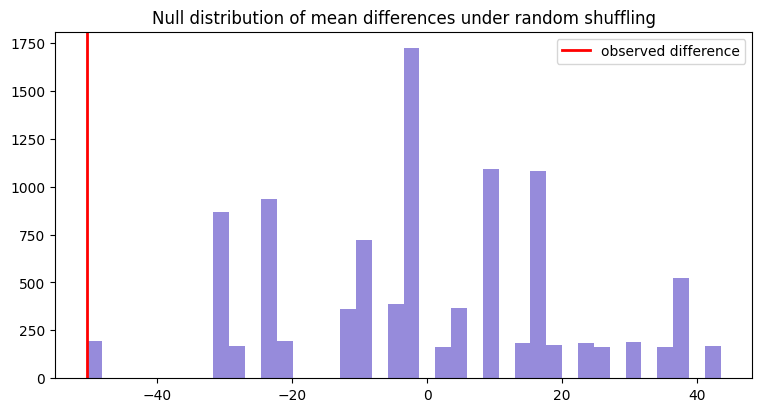

In [19]:
def permutation_test(A, B, n_iter=10000, seed=None, alternative='greater'):
    '''
    Non-parametric permutation test for a difference in means between A and B.
    alternative: 'greater' tests H1: mean(A) - mean(B) > 0
    Returns p-value.
    '''
    rng = np.random.default_rng(seed)
    A, B = np.asarray(A, dtype=float), np.asarray(B, dtype=float)
    observed = A.mean() - B.mean()
    pooled = np.concatenate([A, B])
    n_a = len(A)
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        rng.shuffle(pooled)
        diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    if alternative == 'greater':
        p = np.mean(diffs >= observed)
    elif alternative == 'less':
        p = np.mean(diffs <= observed)
    else:  # two-sided
        p = np.mean(np.abs(diffs) >= abs(observed))
    return p, observed, diffs

A = [3, 5, 4]
B = [43, 41, 56, 78, 54]
p, obs, diffs = permutation_test(A, B, n_iter=10000, seed=7, alternative='greater')
print(f"Observed mean difference (A-B): {obs:.2f}")
print(f"Permutation p-value (H1: A > B): {p:.4f}")

plt.hist(diffs, bins=40, color='slateblue', alpha=0.7)
plt.axvline(obs, color='red', lw=2, label='observed difference')
plt.legend()
plt.title('Null distribution of mean differences under random shuffling')
plt.show()


Compare this permutation test to the Duncan dataset professional-vs-blue-collar
comparison from Module 3 — bootstrapping built a CI for the *difference*,
permutation testing directly asks "how likely is this difference (or bigger)
under the null hypothesis that group labels are meaningless?"


In [20]:
prof_income = df_professional['income'].values
blue_income = df_blue_collar['income'].values

p_two_sided, obs, diffs = permutation_test(prof_income, blue_income, n_iter=10000, seed=11, alternative='two-sided')
print(f"Observed difference in mean income (Professional - Blue-collar): {obs:.2f}")
print(f"Two-sided permutation p-value: {p_two_sided:.4f}")


Observed difference in mean income (Professional - Blue-collar): 36.29
Two-sided permutation p-value: 0.0000


### >>> EXERCISE 4.1 — Combinations in the real world
A lottery draws 6 numbers (no repeats, order doesn't matter) from 49. Use
`itertools.combinations` to compute the number of distinct possible draws and
confirm it against the closed-form formula `C(49, 6)`.


In [21]:
# >>> EXERCISE 4.1 — your code here


### >>> EXERCISE 4.2 — Two-sided vs one-sided permutation tests
Run `permutation_test` on the Duncan `education` variable, comparing `professional`
vs `white-collar` groups, using `alternative='two-sided'`. Then repeat with
`alternative='greater'`. Explain why the two p-values differ and when you would
choose one over the other.


In [22]:
# >>> EXERCISE 4.2 — your code here


---
## Module 5 — Transformations

Many statistical tools (t-tests, linear regression, Pearson correlation, etc.)
assume roughly normal, symmetric data. When data is skewed, a **transformation**
can make it more symmetric before you apply those tools.

Common transforms (all defined for **positive** values only, log/sqrt/cbrt below
require x > 0, x ≥ 0, and any real number respectively):

| Transform | Formula | Use when |
|---|---|---|
| Log | `log(x)` | strong right skew, ratio data, multiplicative relationships |
| Square root | `sqrt(x)` | moderate right skew, count data |
| Cube root | `cbrt(x)` | moderate skew, defined for negative x too |
| Box-Cox | `(x^λ - 1)/λ` | data-driven choice of the "best" power transform |


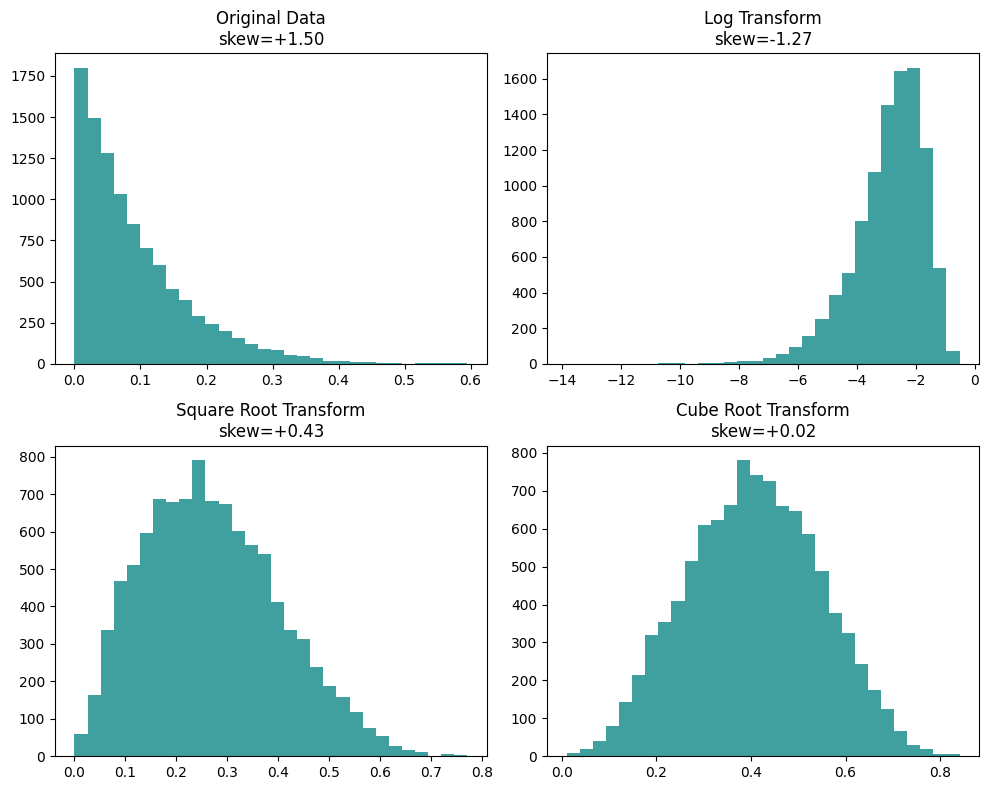

In [23]:
np.random.seed(42)
df = np.random.beta(a=1, b=10, size=10000)   # strongly right-skewed
df_log = np.log(df)
df_sqrt = np.sqrt(df)
df_cbrt = np.cbrt(df)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (title, arr) in zip(axes.ravel(),
        [('Original Data', df), ('Log Transform', df_log),
         ('Square Root Transform', df_sqrt), ('Cube Root Transform', df_cbrt)]):
    ax.hist(arr, bins=30, color='teal', alpha=0.75)
    ax.set_title(f"{title}\nskew={stats.skew(arr):+.2f}")
plt.tight_layout()
plt.show()


Box-Cox chose lambda = 0.303
Skewness before: 1.497  after Box-Cox: -0.061


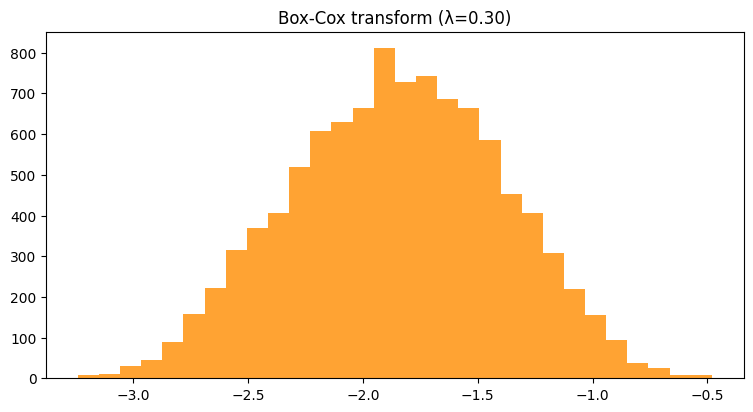

In [24]:
# Box-Cox: let scipy find the "best" lambda automatically
df_positive = df + 1e-6  # Box-Cox requires strictly positive values
bc_values, best_lambda = stats.boxcox(df_positive)
print(f"Box-Cox chose lambda = {best_lambda:.3f}")
print(f"Skewness before: {stats.skew(df):.3f}  after Box-Cox: {stats.skew(bc_values):.3f}")

plt.hist(bc_values, bins=30, color='darkorange', alpha=0.8)
plt.title(f'Box-Cox transform (λ={best_lambda:.2f})')
plt.show()


### >>> EXERCISE 5.1 — Which transform wins?
For each of `df_log`, `df_sqrt`, `df_cbrt`, and `bc_values`, compute
`scipy.stats.skew(...)` and `scipy.stats.shapiro(...)` (a formal normality test —
note `shapiro` can be slow/unstable for very large `n`, so subsample to ~500 points
first). Rank the four transforms from "closest to normal" to "furthest."


In [25]:
# >>> EXERCISE 5.1 — your code here


### >>> EXERCISE 5.2 — Transform a real skewed variable
Use `df_duncan['income']`. Plot a histogram of the raw variable, then of
`np.log1p(income)` (log(1+x), handles zeros safely). Did the transform help?
Compute skewness before/after to support your answer.


In [26]:
# >>> EXERCISE 5.2 — your code here


---
## Module 6 — Capstone: Putting it all together

**Scenario:** You work at the (fictional) factory from Module 1. You want to know
whether **Model B** machines have a different average output than **Model C**
machines, but you only have 12 Model B and 9 Model C output readings (ratio data).

Your task, using tools from every module above:

1. Simulate the two samples (`np.random.normal` or `np.random.gamma` — pick something
   right-skewed to make it interesting) with different means.
2. Classify the data type and justify which descriptive statistics are valid.
3. Visualize both samples (histogram or boxplot) and report skewness/kurtosis.
4. If skewed, apply a transformation and re-check.
5. Run a **permutation test** for a difference in means.
6. Run a **bootstrap** to build a 95% CI for each group's mean and for the
   difference in means.
7. Write 3–4 sentences summarizing your statistical conclusion, and note any
   caveats (sample size, assumptions, simulation vs. real data).

This capstone deliberately has **no single correct answer** — it's meant to
combine the modules the way a real analysis would. Check `solutions_notebook.ipynb`
for one worked version, but yours may reasonably differ.


In [27]:
# >>> CAPSTONE — your code here
